In [2]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [97]:
#Modeling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [98]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [99]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [11]:
#Understanding The Data

In [100]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [15]:
#Clean The Data

In [101]:
#1.Handle Missing Values

df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [17]:
#2.Fill numeric missing values with mean


df.fillna(df.mean(numeric_only=True),inplace=True)

In [44]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [19]:
#Standardize categorical values

In [102]:
df['gender'] = df['gender'].str.lower() 
df['social_interaction_level'] = df['social_interaction_level'].str.lower()

In [23]:

#Mental_Health_Score

In [103]:
df['mental_health_score'] = df[['stress_level',
    'anxiety_level',
    'depression_label']].mean(axis=1)
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1.333333
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,3.000000
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,2.000000
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,2.666667
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,2.666667


In [49]:




#Exploratory Data  Analysis (EDA)




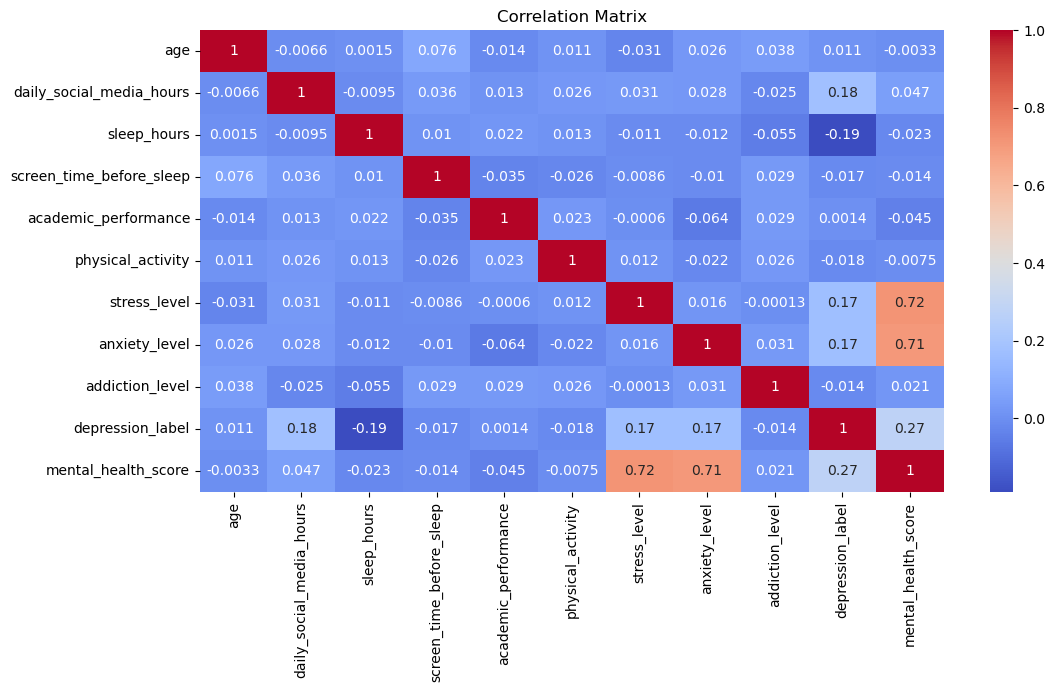

In [104]:
#Correlation Heatmap


plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [113]:
# The heatman above shows the strength and direction of relations between variable.
# I observed that sleep_hours has a negative correlation with mental_health_score, indicating that lower sleep is associated with worse mental health.

In [51]:
#Sleep vs Mental Health

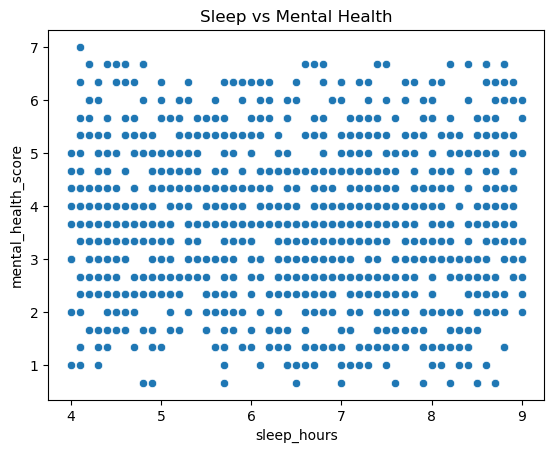

In [105]:
sns.scatterplot(x='sleep_hours', y= 'mental_health_score', data = df)
plt.title("Sleep vs Mental Health")
plt.show()

In [114]:
#There is a clear negative relationship between sleep and mental health score.
#As sleep decrease,suggesting sleep deprivation is key risk factor.

In [53]:
#Social Media vs Anxiety

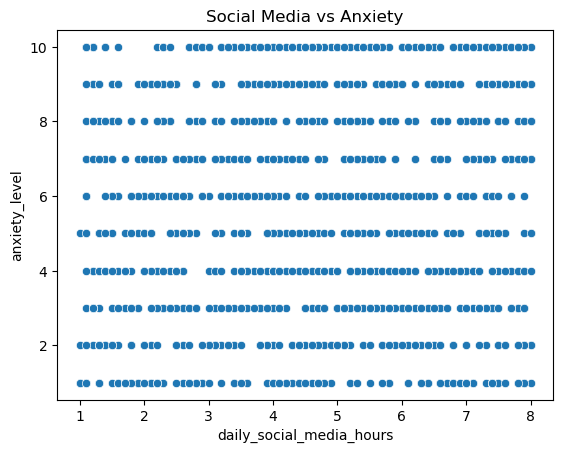

In [106]:
sns.scatterplot(x='daily_social_media_hours', y='anxiety_level',data=df)
plt.title("Social Media vs Anxiety")
plt.show()

In [116]:
#The plot above shows that higher daily social media usage is assciated with increase anxiety levels, indicating excessive usage may negatively
#impact mental well-being.

In [55]:
#Screen Time Before Sleep

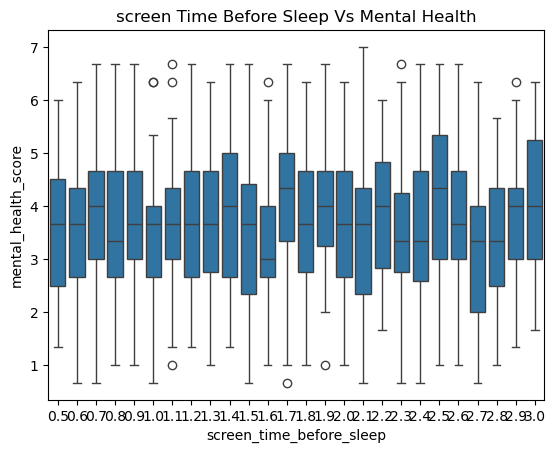

In [107]:
sns.boxplot(x='screen_time_before_sleep', y ='mental_health_score',data = df)
plt.title("screen Time Before Sleep Vs Mental Health")
plt.show()

In [8]:
#The plot above show individual with higer screen time before sleep show higher median mental health score,
#sugesting that late night device usage contributes to proper mental health.

In [57]:
#Platform Usage Impact

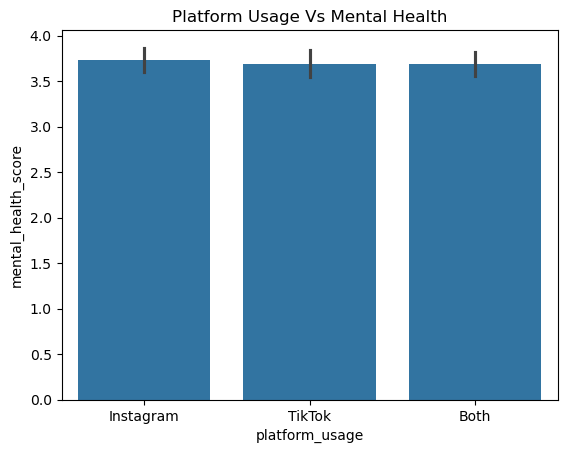

In [108]:
sns.barplot(x='platform_usage',y='mental_health_score',data=df)
plt.title("Platform Usage Vs Mental Health")
plt.show()

In [3]:
#The plot above shows different plateforms show varyin imppacts on mental health.
#Usage of Instagram tend to have higer mental health score, indicating potential platforms specific effects.

In [59]:
#Social Interaction Impact

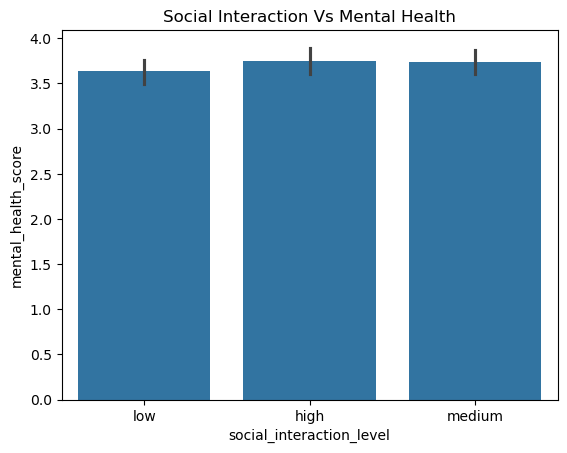

In [109]:
sns.barplot(x='social_interaction_level', y='mental_health_score', data=df)
plt.title("Social Interaction Vs Mental Health")
plt.show()

In [4]:
#Teens with low social interaction show worse mental health outcomes compared to those with high interaction,highlighting the  importance of 
#social connections.

In [67]:
#Modeling(Predictors)

In [110]:
 X = df[['sleep_hours','daily_social_media_hours',
         'screen_time_before_sleep',
         'academic_performance',
         'physical_activity']]
Y = df['mental_health_score']

x_train,x_test, y_train,y_test = train_test_split(x,y,test_size = 0.2)

model = LinearRegression()
model.fit(x_train,y_train)

#Feature importance
importance = pd.DataFrame({'Feature': x.columns,
                           'Impact' : model.coef_}).sort_values(by='Impact', ascending = False)
importance
         

,Feature,Impact
1,daily_social_media_hours,0.048261
4,physical_activity,0.020354
0,sleep_hours,-0.028825
2,screen_time_before_sleep,-0.040538
3,academic_performance,-0.155666


In [5]:
#From the regression model,sleep_hours and social media usage emerge as the strongest predictors of mental health,
#confirming pattterns observed during exploratory analysis.

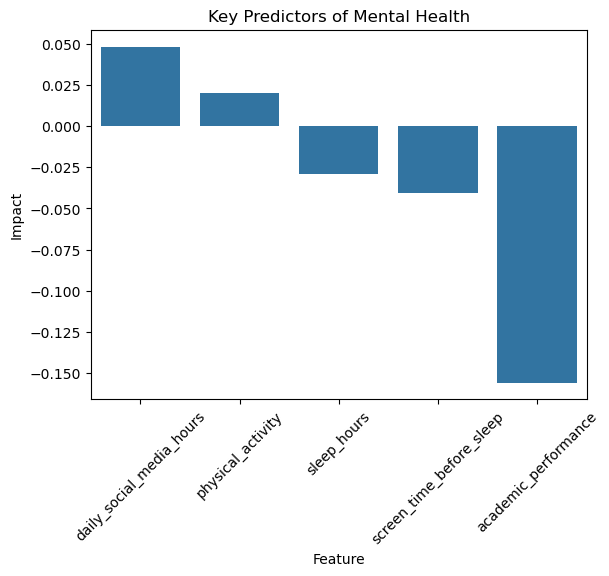

In [111]:
sns.barplot(x='Feature', y='Impact',data=importance)
plt.xticks(rotation=45)
plt.title("Key Predictors of Mental Health")
plt.show()

In [7]:
print("""
1.KEY FACTORS AND EARLY INTERVENTION:
key factors contributing to declining mental health among teenagers include:
1. low sleep hours
2. High daily social media usage
3. Excessive screen time before sleep
4. Low phsical activity 
5. Poor social interaction


                 EXPLANATION
From the analysis:
Sleep showed a negative relationship with mental health,less sleep = worse outcome.
Social media and scrren time showed positive relationships with anxiety and stress.
Teens with low social interaction had higher mental health scores(worse condition)


               EARLY INTERVENTION STRATEGIES
1. SLEEP REGULATION PROGRAMS
. Encourage 7-9 hours of sleep 
. Reduce device usage before bedtime

2. DIGITAL BEHAVIOUR CONTROL:
. Limit daily social media hours
. Promote healthy online habits

3.ENCOURAGE PHYSICAL ACTIVITY 
. Regular excercise reduces stress and anxiety

4. SOCIAL ENAGEMENT:
. Promote peer interaction and group activities

5. SCHOOL-BASE MONITORING:
.Identify at-risk students early using behavioural indicators""")







1.KEY FACTORS AND EARLY INTERVENTION:
key factors contributing to declining mental health among teenagers include:
1. low sleep hours
2. High daily social media usage
3. Excessive screen time before sleep
4. Low phsical activity 
5. Poor social interaction


                 EXPLANATION
From the analysis:
Sleep showed a negative relationship with mental health,less sleep = worse outcome.
Social media and scrren time showed positive relationships with anxiety and stress.
Teens with low social interaction had higher mental health scores(worse condition)


               EARLY INTERVENTION STRATEGIES
1. SLEEP REGULATION PROGRAMS
. Encourage 7-9 hours of sleep 
. Reduce device usage before bedtime

2. DIGITAL BEHAVIOUR CONTROL:
. Limit daily social media hours
. Promote healthy online habits

3.ENCOURAGE PHYSICAL ACTIVITY 
. Regular excercise reduces stress and anxiety

4. SOCIAL ENAGEMENT:
. Promote peer interaction and group activities

5. SCHOOL-BASE MONITORING:
.Identify at-risk stude

In [1]:
print("""
2. STRONGEST PREDICTORS OF POOR MENTAL HEALTH:
The strongest predictors of poor mental health are:
1. Sleep hours(strong negative predictor 
2. Daily social media usage (strong negative predictor)
3. Screen time before sleep
4. physical activity (protective facor)

                             EXPLANATION:
From:
Correlation heatmap.
Regression model(feature importance)

Variable with the highest impact:
. Negative coefficient(sleep)'improves mental health
. Positive coefficients(social media,screen time),worsen mental health

                           INTERPRETATIION 
. Teen who sleep less and use social media more frequently are at the highest risk
. Physical activity helps reduce mental health issues""")


2. STRONGEST PREDICTORS OF POOR MENTAL HEALTH:
The strongest predictors of poor mental health are:
1. Sleep hours(strong negative predictor 
2. Daily social media usage (strong negative predictor)
3. Screen time before sleep
4. physical activity (protective facor)

                             EXPLANATION:
From:
Correlation heatmap.
Regression model(feature importance)

Variable with the highest impact:
. Negative coefficient(sleep)'improves mental health
. Positive coefficients(social media,screen time),worsen mental health

                           INTERPRETATIION 
. Teen who sleep less and use social media more frequently are at the highest risk
. Physical activity helps reduce mental health issues


In [3]:
print("""
3. INTERACTION BETWEEN FACTORS:
Mental health among teens is influence by combined effects of multiple factors, not just one.

                      KEY INTERACTIONS FOUND 
1. High social media and low sleep,lead to the worst mental health outcomes
2. High screen time before sleep,reduced sleep,increases stress and anxiety
3. Good sleep and high physical activity, leads to better mental health outcome
4. Low social interaction and high online activity,increases risk of depression and anxiety

                      EXPLANATION

The interactionn analysis shows that:
. Risk factors compound each other 
. Protective factors(sleep,excercise) can offset negative effects""")


3. INTERACTION BETWEEN FACTORS:
Mental health among teens is influence by combined effects of multiple factors, not just one.

                      KEY INTERACTIONS FOUND 
1. High social media and low sleep,lead to the worst mental health outcomes
2. High screen time before sleep,reduced sleep,increases stress and anxiety
3. Good sleep and high physical activity, leads to better mental health outcome
4. Low social interaction and high online activity,increases risk of depression and anxiety

                      EXPLANATION

The interactionn analysis shows that:
. Risk factors compound each other 
. Protective factors(sleep,excercise) can offset negative effects


In [2]:
print("""
KEY RECOMMENDATION:
1. Promote better sleep habits among teens 
2. Limit excessive social media usage 
3. Reduce screen expossure before bedtime
4. Encourage physical activity 
5. Early identification of high-risk individuals """)


KEY RECOMMENDATION:
1. Promote better sleep habits among teens 
2. Limit excessive social media usage 
3. Reduce screen expossure before bedtime
4. Encourage physical activity 
5. Early identification of high-risk individuals 
